# ЛАБОРАТОРНАЯ 8
Тема: Классификация изображений с помощью нейронной сети.

Постановка: Взять предобученную нс, провести ее заморозку, убрать оригинальные слои, добавить новые. В итоге, обучить новые слои для задачи классификации изображений с EuroSAT.

Цель: Проинтерпретировать и продемонстрировать полученные результаты.


## Загружаем данные EuroSAT и выбираем модель НС


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import numpy as np
from sklearn.model_selection import train_test_split

In [28]:
# 1. Загрузка данных EuroSAT
data_dir = '/content/drive/MyDrive/Colab Notebooks/8 лаба/EuroSAT_RGB/EuroSAT_RGB'
img_size = (64, 64)
batch_size = 32

# Создаем датасет из папки
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# Проверяем классы
class_names = train_ds.class_names
print("Классы:", class_names)
print("Количество классов:", len(class_names))

# 2. Выбор предобученной сети
# Возьмем EfficientNetB0 с весами ImageNet
model_name = "EfficientNetB0"
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False, # Убрал оригинальные слои классификации
    weights='imagenet',
    input_shape=(64, 64, 3)
)

Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.
Классы: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Количество классов: 10


## Добавление новых слоев

In [25]:
# 3. Создаем новую модель
base_model.trainable = False  # Замораживаем

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Компилируем
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Обучение

In [26]:
# 4. Обучаем
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=2)
]

history = model.fit(
    train_ds,
    epochs=8,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 787s 1s/step - accuracy: 0.7739 - loss: 0.6802 - val_accuracy: 0.9115 - val_loss: 0.2652 - learning_rate: 0.0010
Epoch 2/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 291s 430ms/step - accuracy: 0.8905 - loss: 0.3243 - val_accuracy: 0.9161 - val_loss: 0.2507 - learning_rate: 0.0010
Epoch 3/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 262s 389ms/step - accuracy: 0.9031 - loss: 0.2869 - val_accuracy: 0.9204 - val_loss: 0.2381 - learning_rate: 0.0010
Epoch 4/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 316s 379ms/step - accuracy: 0.9126 - loss: 0.2528 - val_accuracy: 0.9222 - val_loss: 0.2300 - learning_rate: 0.0010
Epoch 5/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 252s 374ms/step - accuracy: 0.9189 - loss: 0.2376 - val_accuracy: 0.9263 - val_loss: 0.2241 - learning_rate: 0.0010
Epoch 6/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 285s 422ms/step - accuracy: 0.9231 - loss: 0.2255 - val_accuracy: 0.9276 - val_loss: 0.2197 - learning_rate: 0.0010
Epoch 7/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 254s 375ms/step - accuracy: 0.9235

## Результаты

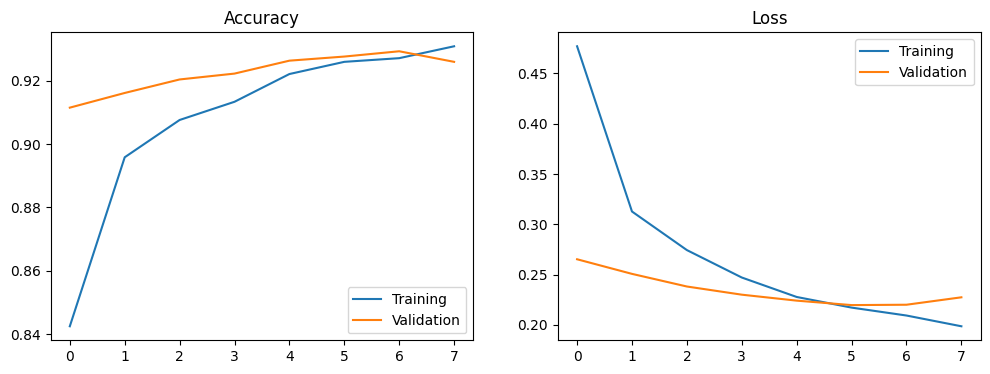

Лучшая точность на валидации: 0.9293


In [27]:
# 5. Демонстрируем результаты
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title('Loss')

plt.show()

final_val_acc = max(history.history['val_accuracy'])
print(f"Лучшая точность на валидации: {final_val_acc:.4f}")

**Вывод:** за счет использования предобученной сверточной нс EfficientNetB0, дальнейшего ее замораживания и впоследствии созданных новых слоев успешно решили задачу классификации спутниковых снимков с точностью 0.93, что я считаю достойным результатом с учетом модели и ресурсов, которые были использованы